In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans
from geopy.distance import geodesic

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

train_df = pd.read_csv('../data/train(1).csv')
test_df = pd.read_csv("../data/test2.csv") 

In [2]:
def validate_sqft(df):
  
    discrepancy = df[df['sqft_living'] != (df['sqft_above'] + df['sqft_basement'])]
    if len(discrepancy) > 0:
        print(f"[*] Found {len(discrepancy)} rows with sqft mismatches. Fixing...")
        df['sqft_living'] = df['sqft_above'] + df['sqft_basement']

    df = df[df['bedrooms'] > 0]
    df = df[df['sqft_living'] > 200]
    return df

train_df = validate_sqft(train_df)

In [3]:
def add_geo_clusters(train, test, n_clusters=20):
    coords = train[['lat', 'long']]
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    
    train['cluster_id'] = kmeans.fit_predict(coords)
  
    test['cluster_id'] = kmeans.predict(test[['lat', 'long']])
    return train, test

train_df, test_df = add_geo_clusters(train_df, test_df)

In [4]:
SEATTLE_CENTER = (47.6062, -122.3321)

def calculate_distance(row):
    return geodesic((row['lat'], row['long']), SEATTLE_CENTER).miles

train_df['dist_to_downtown'] = train_df.apply(calculate_distance, axis=1)
test_df['dist_to_downtown'] = test_df.apply(calculate_distance, axis=1)

In [5]:
def generate_heatmap(df):
    m = folium.Map(
        location=[df.lat.mean(), df.long.mean()], 
        zoom_start=10, 
        tiles='CartoDB positron' 
    )
    
    #Clean the data:
    heat_df = df[['lat', 'long', 'price']].dropna()
    
    #Convert to list format
    heat_data = [[row['lat'], row['long'], row['price']] for index, row in heat_df.iterrows()]
    
    #Add the heatmap layer
    HeatMap(
        heat_data, 
        radius=8, 
        blur=12, 
        max_zoom=1,
        gradient={0.4: 'blue', 0.6: 'cyan', 0.7: 'lime', 0.8: 'yellow', 1: 'red'}
    ).add_to(m)
    
    return m

# Call this in your notebook to see the map
heatmap = generate_heatmap(train_df)
heatmap.save("price_heatmap.html")


Original Price Skew: 4.03
Log Price Skew: 0.41


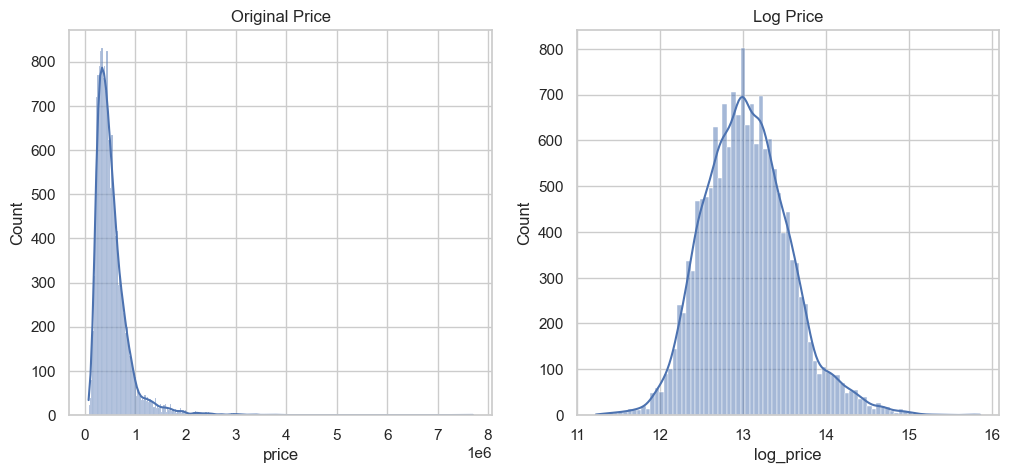

In [6]:
# Check skewness
print(f"Original Price Skew: {train_df['price'].skew():.2f}")

# Transform
train_df['log_price'] = np.log1p(train_df['price'])
print(f"Log Price Skew: {train_df['log_price'].skew():.2f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(train_df['price'], ax=ax1, kde=True).set_title("Original Price")
sns.histplot(train_df['log_price'], ax=ax2, kde=True).set_title("Log Price")
plt.show()

In [7]:
train_df.to_csv("../data/train_processed.csv", index=False)
test_df.to_csv("../data/test_processed.csv", index=False)
print("  Preprocessing Completed. Files saved for Model Training.")

  Preprocessing Completed. Files saved for Model Training.
